## Introduction 
### Background Info
...

In [23]:
# Loading the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sb

In [24]:
rawHousingData = pd.read_csv("https://raw.githubusercontent.com/wilkmzhou/vancouverHousePricePrediction/refs/heads/main/synthetic_house_prices_20_years.csv")

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 500)

print(rawHousingData.head(n = 3))
print(len(rawHousingData))



  Neighborhood  Year  Season Property Type  Bedrooms  Bathrooms  Year Built  Renovation Year Garage Type  Square Footage (House)  Square Footage (Land)      Basement  Legal Units  Market Price
0    Kitsilano  2004  Spring       Triplex         1          3        1954           2000.0      Double                    1308                   6742  Not Finished            2    1734587.40
1    Kitsilano  2004  Summer         Condo         3          1        2022              NaN      Single                    3947                   2592      Finished            0     951731.62
2    Kitsilano  2004    Fall         House         4          1        2006              NaN         NaN                     919                   9519  Not Finished            2    1782016.80
3520


### Exploratory Data Analysis

In [32]:
NrawHousingData = rawHousingData.select_dtypes(include = "number")
corr = NrawHousingData.corr()
corr.style.background_gradient(cmap = "coolwarm").format(precision = 3)

,Year,Bedrooms,Bathrooms,Year Built,Renovation Year,Square Footage (House),Square Footage (Land),Legal Units,Market Price
Year,1.000,0.009,0.030,-0.006,-0.002,0.027,-0.012,-0.034,0.440
Bedrooms,0.009,1.000,-0.004,-0.000,0.003,-0.013,-0.018,-0.025,-0.007
Bathrooms,0.030,-0.004,1.000,0.023,0.012,-0.011,0.011,0.007,-0.003
Year Built,-0.006,-0.000,0.023,1.000,0.633,-0.014,-0.000,-0.005,0.012
Renovation Year,-0.002,0.003,0.012,0.633,1.000,-0.014,0.006,-0.012,0.027
Square Footage (House),0.027,-0.013,-0.011,-0.014,-0.014,1.000,0.023,-0.030,0.009
Square Footage (Land),-0.012,-0.018,0.011,-0.000,0.006,0.023,1.000,-0.003,0.000
Legal Units,-0.034,-0.025,0.007,-0.005,-0.012,-0.030,-0.003,1.000,0.006
Market Price,0.440,-0.007,-0.003,0.012,0.027,0.009,0.000,0.006,1.000


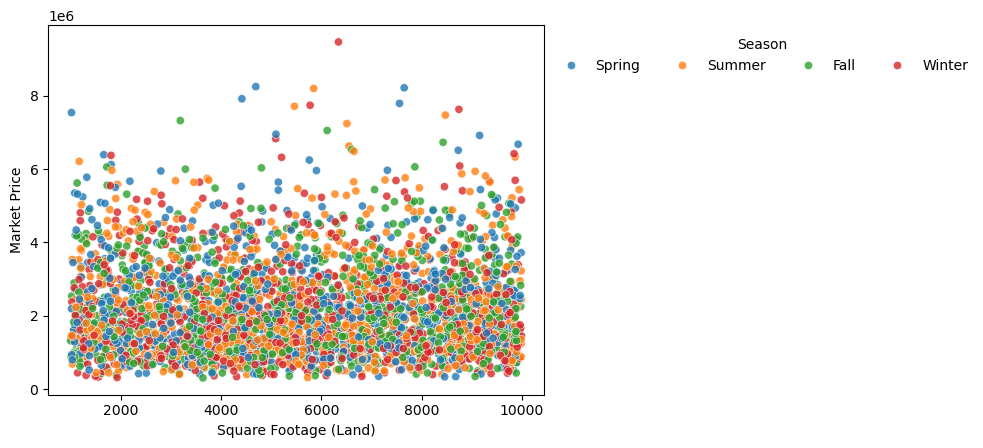

In [41]:
Sq_Mp_Neigh_Plot = sb.scatterplot(data = rawHousingData, x = "Square Footage (Land)", y = "Market Price", hue = "Season", alpha = 0.8)
sb.move_legend(Sq_Mp_Neigh_Plot, "upper left", bbox_to_anchor= (1,1), frameon = False, ncol = 4)

In [3]:
rawHousingData["is_Renovated"] = rawHousingData["Renovation Year"].isnull().astype(int)
rawHousingData["adjusted_house_age"] = 2024 - rawHousingData[["Year Built", "Renovation Year"]].max(axis = 1)
rawHousingData["Garage Type"] = rawHousingData["Garage Type"].fillna("No Garage")
rawHousingData = rawHousingData.drop(columns =["Renovation Year"],axis = 1)


housingData = rawHousingData.dropna()
housingData = housingData.drop_duplicates()

print(housingData.head(n = 3))
print(len(housingData))


  Neighborhood  Year  Season Property Type  Bedrooms  Bathrooms  Year Built  ... Square Footage (House)  Square Footage (Land)      Basement Legal Units  Market Price  is_Renovated  adjusted_house_age
0    Kitsilano  2004  Spring       Triplex         1          3        1954  ...                   1308                   6742  Not Finished           2    1734587.40             0                24.0
1    Kitsilano  2004  Summer         Condo         3          1        2022  ...                   3947                   2592      Finished           0     951731.62             1                 2.0
2    Kitsilano  2004    Fall         House         4          1        2006  ...                    919                   9519  Not Finished           2    1782016.80             1                18.0

[3 rows x 15 columns]
3520
